# IQR Method
The **IQR (Interquartile Range) method** is a robust statistical technique  used to identify outliers by calculating the range between the 75th () and 25th () percentiles. It determines outliers as values falling
- below *Q1 - 1.5 x IQR*
- above *Q1 + 1.5 x IQR*

 making it ideal for skewed dataset

## Steps to Use the IQR Method
1. Order Data: Sort the dataset in ascending order.
2. Find Quartiles: Calculate
    - Q1 (25th percentile) and
    - Q3 (75th percentile).

3. Calculate IQR: Compute the difference:
    - **IQR = Q3 -Q1**
4. Determine Boundaries:
    - Lower Fence: *Q1 - 1.5 x IQR*
    - Upper Fence: *Q1 + 1.5 x IQR*

5. Identify Outliers: Any data point smaller than the lower fence or larger than the upper fence is an outlier.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from mpmath import cond

warnings.filterwarnings('ignore')


In [7]:
df = pd.read_csv("placement.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

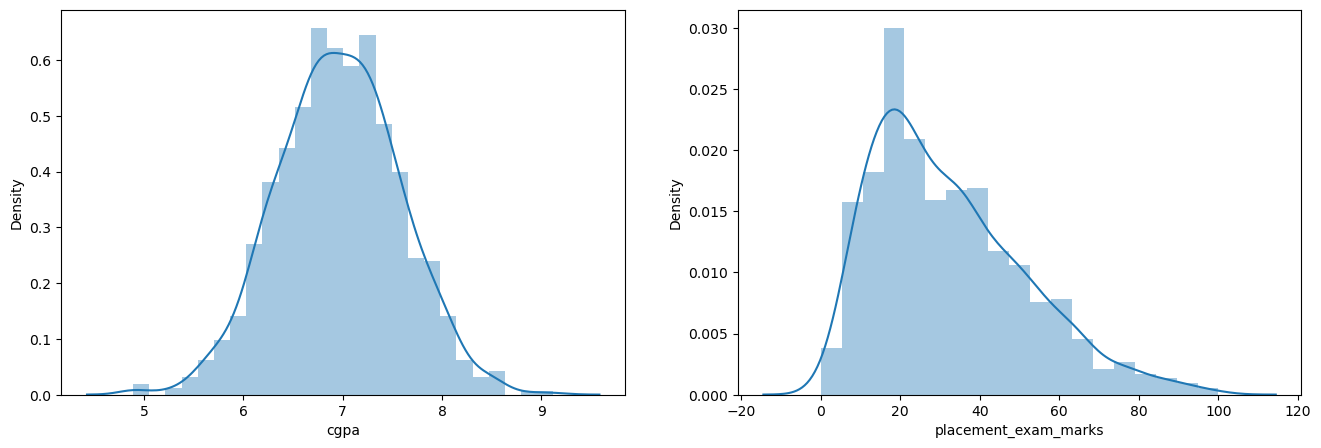

In [10]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.distplot(df['cgpa'])

plt.subplot(122)
sns.distplot(df['placement_exam_marks'])

In [11]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [12]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [14]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

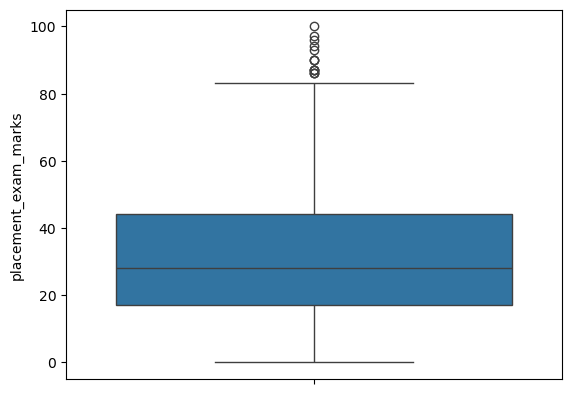

In [16]:
sns.boxplot(df['placement_exam_marks'])

In [17]:
# Finding the IQR

per_25 = df['placement_exam_marks'].quantile(0.25)
per_75 = df['placement_exam_marks'].quantile(0.75)

In [20]:
iqr = per_75 - per_25
iqr

np.float64(27.0)

In [21]:
upr_limit = per_75 + 1.5 *iqr
lwr_limit = per_25 - 1.5 *iqr

In [22]:
print("Upper limit: ", upr_limit)
print("Lower limit: ", lwr_limit)

Upper limit:  84.5
Lower limit:  -23.5


Finding Outliers

In [23]:
df[df['placement_exam_marks'] > upr_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [24]:
df[df['placement_exam_marks'] < lwr_limit]

,cgpa,placement_exam_marks,placed


Trimming

In [25]:
new_df = df[df['placement_exam_marks'] < upr_limit]
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: ylabel='placement_exam_marks'>

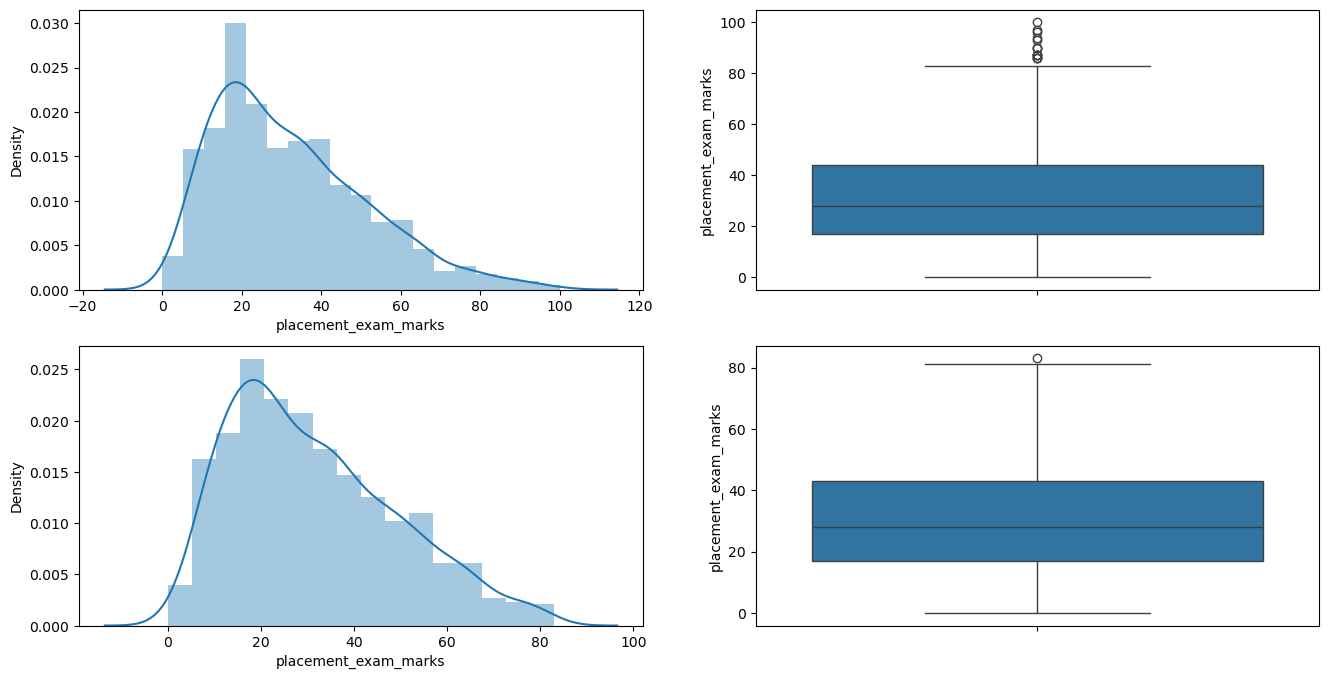

In [26]:
#comparing

plt.figure(figsize=(16,8))
plt.subplot(221)
sns.distplot(df['placement_exam_marks'])

plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(223)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(224)
sns.boxplot(new_df['placement_exam_marks'])

Capping

In [27]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upr_limit,
    upr_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lwr_limit,
        lwr_limit,
        new_df_cap['placement_exam_marks']
    )
)

<Axes: ylabel='placement_exam_marks'>

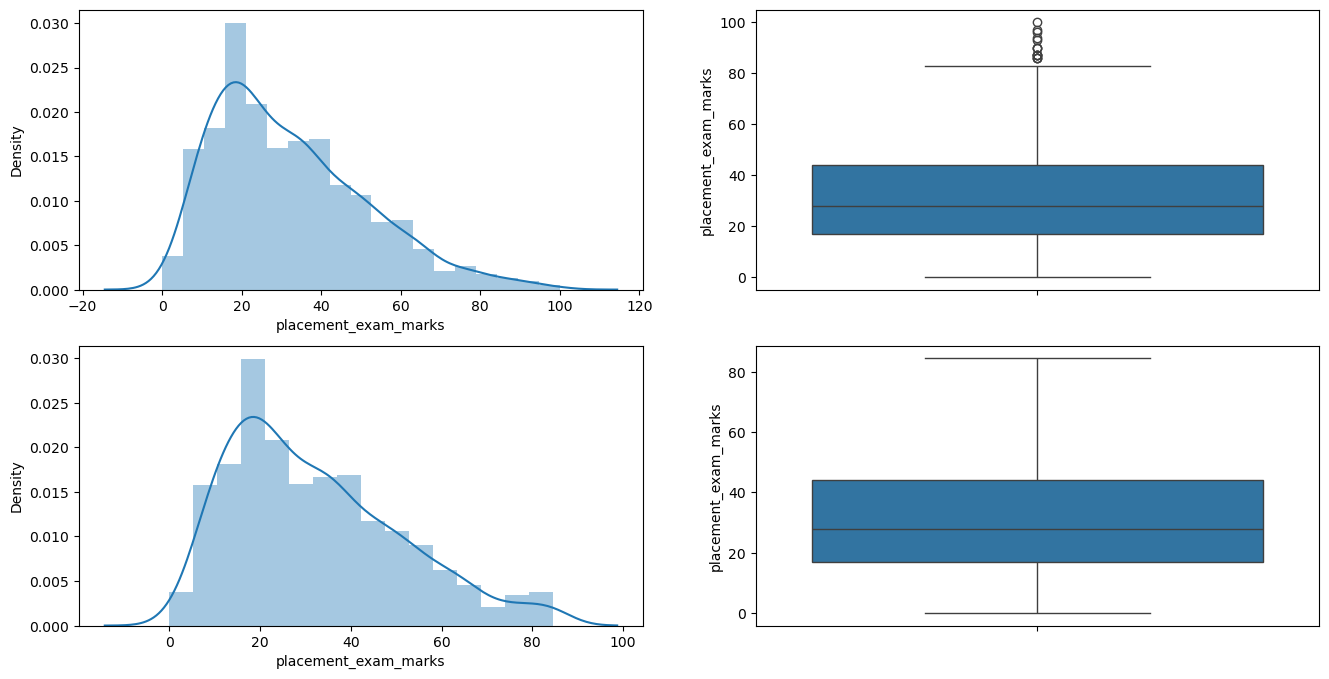

In [28]:
#comparing

plt.figure(figsize=(16,8))
plt.subplot(221)
sns.distplot(df['placement_exam_marks'])

plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(223)
sns.distplot(new_df_cap['placement_exam_marks'])

plt.subplot(224)
sns.boxplot(new_df_cap['placement_exam_marks'])